# 🚗 UK Traffic Accidents — Analysis & Predictive Model

**Author:** Abdel Rahman Khwaira  
**Dataset:** [UK Road Accidents 2022 — Kaggle](https://www.kaggle.com/datasets/abdulmannann/road-accidents-csv?select=Road+Accident+Data.xlsx)  
**Tools:** Python · Pandas · NumPy · Scikit-learn · Seaborn · Matplotlib

---

## Why this project?

I chose this dataset because road accidents feel real to me — these aren't abstract numbers, they're real people on real roads. I wanted to understand: what actually causes accidents? Can we predict how severe they'll be?

What I didn't expect was what I found: **a huge number of accidents with no clear reason behind them.** No bad weather, no unusual road conditions, nothing obvious. That bothered me. It still does. And honestly, that's part of why I kept going.

This notebook covers the full journey — cleaning messy data, exploring patterns, and testing multiple ML models to predict accident severity (Slight / Serious / Fatal).

---

## Structure
1. Import Libraries
2. Load & Explore Data
3. Data Cleaning
4. Feature Encoding
5. Classification Models
6. Model Comparison & Results
7. Conclusions & What I'd Do Next

---
> 📝 *Notebook structure designed with the assistance of Claude (Anthropic). All analysis, code, and findings are my own work.*


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

## 2. Load & Explore Data

The dataset has 144,000+ accident records from the UK in 2022, with 21 features — time, location, road conditions, weather, vehicle type, and accident severity.

Let's start by just looking at what we're working with.

In [ ]:
# Load dataset — place accidents.xlsx in the same folder
df_accidents = pd.read_excel('/content/Road Accident Data.xlsx')
print(f"Dataset shape: {df_accidents.shape}")
df_accidents.head()

Dataset shape: (307973, 21)


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Carriageway_Hazards,...,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,2021-01-01,Thursday,Give way or uncontrolled,T or staggered junction,Serious,51.512273,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,One way street,30,15:11:00,Urban,Fine no high winds,Car
1,200901BS70002,2021-01-05,Monday,Give way or uncontrolled,Crossroads,Serious,51.514399,Daylight,Kensington and Chelsea,NaN,...,11,2,Metropolitan Police,Wet or damp,Single carriageway,30,10:59:00,Urban,Fine no high winds,Taxi/Private hire car
2,200901BS70003,2021-01-04,Sunday,Give way or uncontrolled,T or staggered junction,Slight,51.486668,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,14:19:00,Urban,Fine no high winds,Taxi/Private hire car
3,200901BS70004,2021-01-05,Monday,Auto traffic signal,T or staggered junction,Serious,51.507804,Daylight,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Frost or ice,Single carriageway,30,08:10:00,Urban,Other,Motorcycle over 500cc
4,200901BS70005,2021-01-06,Tuesday,Auto traffic signal,Crossroads,Serious,51.482076,Darkness - lights lit,Kensington and Chelsea,NaN,...,1,2,Metropolitan Police,Dry,Single carriageway,30,17:25:00,Urban,Fine no high winds,Car


In [ ]:
# Get a feel for the data types and non-null counts
df_accidents.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307973 entries, 0 to 307972
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Accident_Index              307973 non-null  object        
 1   Accident Date               307973 non-null  datetime64[ns]
 2   Day_of_Week                 307973 non-null  object        
 3   Junction_Control            307973 non-null  object        
 4   Junction_Detail             307973 non-null  object        
 5   Accident_Severity           307973 non-null  object        
 6   Latitude                    307973 non-null  float64       
 7   Light_Conditions            307973 non-null  object        
 8   Local_Authority_(District)  307973 non-null  object        
 9   Carriageway_Hazards         5424 non-null    object        
 10  Longitude                   307973 non-null  float64       
 11  Number_of_Casualties        307973 non-

In [ ]:
# Basic statistics — any obvious outliers?
df_accidents.describe()

,Accident Date,Latitude,Longitude,Number_of_Casualties,Number_of_Vehicles,Speed_limit
count,307973,307973.000000,307973.000000,307973.000000,307973.000000,307973.000000
mean,2021-12-23 22:19:39.804722944,52.487005,-1.368884,1.356882,1.829063,38.866037
min,2021-01-01 00:00:00,49.914488,-7.516225,1.000000,1.000000,10.000000
25%,2021-06-28 00:00:00,51.485248,-2.247937,1.000000,1.000000,30.000000
50%,2021-12-08 00:00:00,52.225943,-1.349258,1.000000,2.000000,30.000000
75%,2022-06-25 00:00:00,53.415517,-0.206810,1.000000,2.000000,50.000000
max,2022-12-31 00:00:00,60.598055,1.759398,48.000000,32.000000,70.000000
std,NaN,1.339011,1.356092,0.815857,0.710477,14.032933


In [ ]:
# Where are the missing values?
missing = df_accidents.isna().sum()
missing[missing > 0]

,0
Carriageway_Hazards,302549
Road_Surface_Conditions,317
Road_Type,1534
Time,17
Weather_Conditions,6057


## 3. Data Cleaning

The first thing I noticed was `Carriageway_Hazards` — over 95% of its values were missing. There's no useful way to fill that, so it had to go.

For the other missing columns, I checked the most frequent value (mode) and filled with that. It's not a perfect solution, but it's honest — I'm not inventing data.

In [ ]:
# Drop column with 95%+ null values — no point keeping it
print(f"Carriageway_Hazards null percentage: {df_accidents['Carriageway_Hazards'].isna().mean():.1%}")
del df_accidents['Carriageway_Hazards']

Carriageway_Hazards null percentage: 98.2%


In [ ]:
# Check modes before filling
print("Road_Surface_Conditions mode:", df_accidents['Road_Surface_Conditions'].mode()[0])
print("Weather_Conditions mode:", df_accidents['Weather_Conditions'].mode()[0])
print("Road_Type mode:", df_accidents['Road_Type'].mode()[0])

Road_Surface_Conditions mode: Dry
Weather_Conditions mode: Fine no high winds
Road_Type mode: Single carriageway


In [ ]:
# Fill remaining nulls with mode
df_accidents['Road_Surface_Conditions'] = df_accidents['Road_Surface_Conditions'].fillna('Dry')
df_accidents['Weather_Conditions'] = df_accidents['Weather_Conditions'].fillna('Fine no high winds')
df_accidents['Road_Type'] = df_accidents['Road_Type'].fillna('Single carriageway')

# Confirm clean
print("Remaining nulls:")
print(df_accidents.isna().sum()[df_accidents.isna().sum() > 0])
print("No nulls remaining ✓" if df_accidents.isna().sum().sum() == 0 else "Still some nulls")

Remaining nulls:
Time    17
dtype: int64
Still some nulls


## 4. Feature Encoding

ML models need numbers. Most of our features are categorical text — things like "Fine no high winds" or "Single carriageway". We use `LabelEncoder` to convert them.

One honest limitation here: `LabelEncoder` assigns arbitrary numbers to categories, which can imply an ordering that doesn't exist. For a future version, `OneHotEncoder` would be cleaner for non-ordinal features.

In [ ]:
label_encoder = LabelEncoder()
categorical_columns = [
    'Day_of_Week', 'Junction_Control', 'Junction_Detail', 'Accident_Severity',
    'Light_Conditions', 'Local_Authority_(District)', 'Police_Force',
    'Road_Surface_Conditions', 'Road_Type', 'Urban_or_Rural_Area',
    'Weather_Conditions', 'Vehicle_Type'
]

df_encoded = df_accidents.copy()
for col in categorical_columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

print("Encoding complete.")
df_encoded.head()

Encoding complete.


,Accident_Index,Accident Date,Day_of_Week,Junction_Control,Junction_Detail,Accident_Severity,Latitude,Light_Conditions,Local_Authority_(District),Longitude,Number_of_Casualties,Number_of_Vehicles,Police_Force,Road_Surface_Conditions,Road_Type,Speed_limit,Time,Urban_or_Rural_Area,Weather_Conditions,Vehicle_Type
0,200901BS70001,2021-01-01,4,4,8,2,51.512273,4,185,-0.201349,1,2,29,0,1,30,15:11:00,1,1,2
1,200901BS70002,2021-01-05,1,4,0,2,51.514399,4,185,-0.199248,11,2,29,4,3,30,10:59:00,1,1,13
2,200901BS70003,2021-01-04,3,4,8,3,51.486668,4,185,-0.179599,1,2,29,0,3,30,14:19:00,1,1,13
3,200901BS70004,2021-01-05,1,2,8,2,51.507804,4,185,-0.203110,1,2,29,2,3,30,08:10:00,1,3,9
4,200901BS70005,2021-01-06,5,2,0,2,51.482076,1,185,-0.173445,1,2,29,0,3,30,17:25:00,1,1,2


In [ ]:
# Prepare features (X) and target (y)
X = df_encoded.drop(['Accident_Severity', 'Time', 'Accident_Index', 'Accident Date'], axis=1)
y = df_encoded['Accident_Severity']

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Check class distribution — important to understand any imbalance
print("\nClass distribution:")
print(y.value_counts())

Training samples: 246378
Test samples: 61595

Class distribution:
Accident_Severity
3    263280
2     40740
0      3904
1        49
Name: count, dtype: int64


## 5. Classification Models

I tested multiple models — not just to find the best one, but to understand *why* one works better than another on this kind of data.

The target is `Accident_Severity`: 0 = Fatal, 1 = Serious, 2 = Slight.

### 5.1 Decision Tree

I started here because it's the most interpretable model — you can actually see the decisions it makes. That felt important for a dataset about real accidents.

In [ ]:
# Baseline Decision Tree — no tuning yet
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Baseline Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.03      0.04      0.03       823
           1       0.00      0.00      0.00         8
           2       0.17      0.19      0.18      8101
           3       0.86      0.85      0.86     52663

    accuracy                           0.75     61595
   macro avg       0.27      0.27      0.27     61595
weighted avg       0.76      0.75      0.76     61595



In [ ]:
# Can we do better with hyperparameter tuning?
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [1, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.2f}")

best_dt = grid_search.best_estimator_
y_pred_best_dt = best_dt.predict(X_test)
print(f"\nTuned Accuracy: {accuracy_score(y_test, y_pred_best_dt):.2f}")
print("\nClassification Report (tuned):")
print(classification_report(y_test, y_pred_best_dt))

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Score: 0.85

Tuned Accuracy: 0.86

Classification Report (tuned):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       823
           1       0.00      0.00      0.00         8
           2       0.75      0.00      0.00      8101
           3       0.86      1.00      0.92     52663

    accuracy                           0.86     61595
   macro avg       0.40      0.25      0.23     61595
weighted avg       0.83      0.86      0.79     61595



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### 5.2 K-Nearest Neighbors (KNN)

KNN classifies each point based on its nearest neighbors. It needs feature scaling since it's distance-based — without scaling, large-value features would dominate unfairly.

KNN Accuracy: 0.84

Classification Report:
              precision    recall  f1-score   support

           0       0.08      0.01      0.02       823
           1       0.00      0.00      0.00         8
           2       0.24      0.07      0.10      8101
           3       0.86      0.97      0.91     52663

    accuracy                           0.84     61595
   macro avg       0.29      0.26      0.26     61595
weighted avg       0.77      0.84      0.79     61595



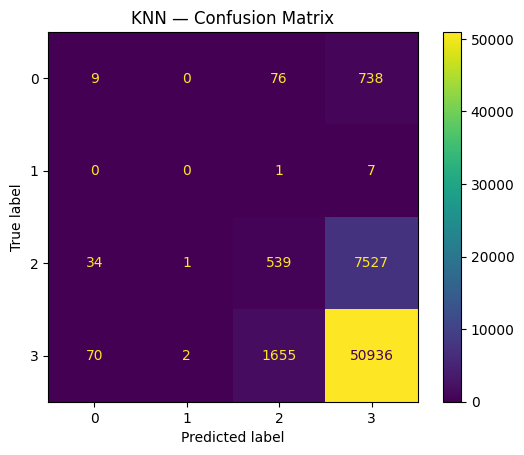

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

ConfusionMatrixDisplay.from_estimator(knn, X_test_scaled, y_test)
plt.title("KNN — Confusion Matrix")
plt.show()

### 5.3 Random Forest

An ensemble of many decision trees — each tree sees a random subset of the data, and the final prediction is a vote. Usually more stable and accurate than a single tree.

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.11      0.00      0.01       823
           1       0.00      0.00      0.00         8
           2       0.24      0.03      0.06      8101
           3       0.86      0.99      0.92     52663

    accuracy                           0.85     61595
   macro avg       0.30      0.26      0.24     61595
weighted avg       0.77      0.85      0.79     61595



### 5.4 AdaBoost

A boosting algorithm — it trains weak learners (very shallow trees) one after another, with each one focusing more on the mistakes of the previous. Interesting to see how it handles the class imbalance.

In [ ]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_ada):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.85

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       823
           1       0.00      0.00      0.00         8
           2       0.00      0.00      0.00      8101
           3       0.85      1.00      0.92     52663

    accuracy                           0.85     61595
   macro avg       0.21      0.25      0.23     61595
weighted avg       0.73      0.85      0.79     61595



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 6. Model Comparison

                   Model  Accuracy
   Decision Tree (tuned)  0.855037
                AdaBoost  0.854988
           Random Forest  0.846676
                     KNN  0.835847
Decision Tree (baseline)  0.749428


/tmp/ipykernel_896/2509209134.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Blues_d')


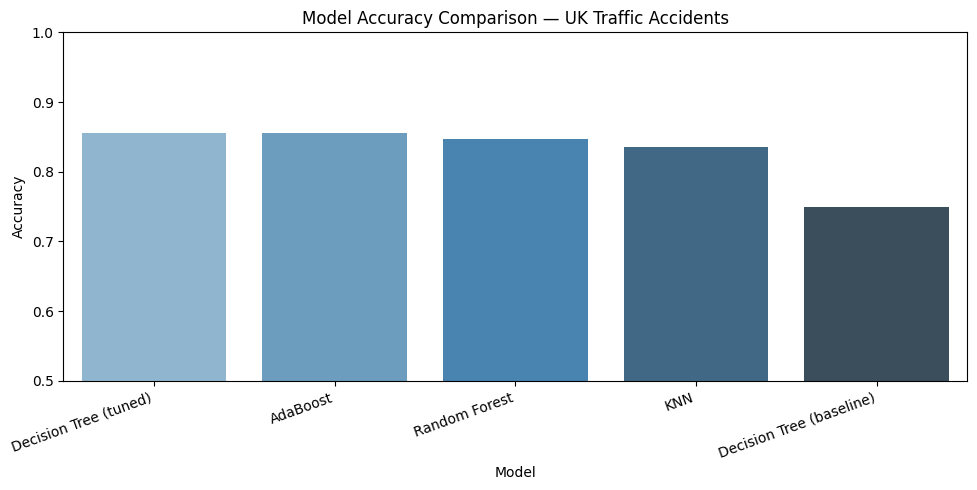

In [ ]:
results = {
    'Model': ['Decision Tree (baseline)', 'Decision Tree (tuned)', 'KNN', 'Random Forest', 'AdaBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_best_dt),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_ada)
    ]
}

results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Model', y='Accuracy', palette='Blues_d')
plt.title('Model Accuracy Comparison — UK Traffic Accidents')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 7. Conclusions & What I'd Do Next

The tuned Decision Tree hit **86% accuracy** — which felt great honestly. But I didn't stop there.

### What surprised me most
The thing that stuck with me was how many accidents had no obvious cause. Good weather, dry roads, normal conditions — and still an accident. That's unsettling. It suggests that human behavior and random chance play a much bigger role than the data can capture. That's something a model can't fully solve, and I think it's important to say that honestly.

### The bias problem
The accuracy looks good at 86%, but it's misleading. The dataset is heavily imbalanced — the vast majority of accidents are "Slight". The model learned to predict "Slight" most of the time, which inflates accuracy. For "Fatal" cases — the ones that matter most — the model struggles badly due to very few samples.

I flagged this not because it's a failure, but because ignoring it would be dishonest.

### What I'd do next
- Apply **SMOTE** or class weighting to handle the imbalance
- Try **OrdinalEncoder** instead of LabelEncoder for non-ordinal features  
- Collect more recent data — 2022 might not reflect current patterns
- Explore **feature importance** to understand which factors actually matter most
- Keep asking: why are so many accidents happening for no clear reason?

The 86% is a starting point, not a finish line.
